
Kasus: Ekstrem Bawah
Tingkat Kerusakan: 0%
Jumlah Laporan: 0
  Kerusakan → {'Rendah': 1.0, 'Sedang': 0.0, 'Tinggi': 0.0}
  Laporan   → {'Sedikit': 1.0, 'Sedang': 0.0, 'Banyak': 0.0}

Kasus: Kondisi Tengah
Tingkat Kerusakan: 50%
Jumlah Laporan: 50
  Kerusakan → {'Rendah': 0.0, 'Sedang': 1.0, 'Tinggi': 0.0}
  Laporan   → {'Sedikit': 0.0, 'Sedang': 1.0, 'Banyak': 0.0}

Kasus: Batas Transisi Bawah
Tingkat Kerusakan: 40%
Jumlah Laporan: 40
  Kerusakan → {'Rendah': 0.0, 'Sedang': 0.5, 'Tinggi': 0.0}
  Laporan   → {'Sedikit': 0.0, 'Sedang': 0.5, 'Banyak': 0.0}

Kasus: Batas Transisi Atas
Tingkat Kerusakan: 60%
Jumlah Laporan: 60
  Kerusakan → {'Rendah': 0.0, 'Sedang': 0.5, 'Tinggi': 0.0}
  Laporan   → {'Sedikit': 0.0, 'Sedang': 0.5, 'Banyak': 0.0}

Kasus: Ekstrem Atas
Tingkat Kerusakan: 100%
Jumlah Laporan: 100
  Kerusakan → {'Rendah': 0.0, 'Sedang': 0.0, 'Tinggi': 1.0}
  Laporan   → {'Sedikit': 0.0, 'Sedang': 0.0, 'Banyak': 1.0}


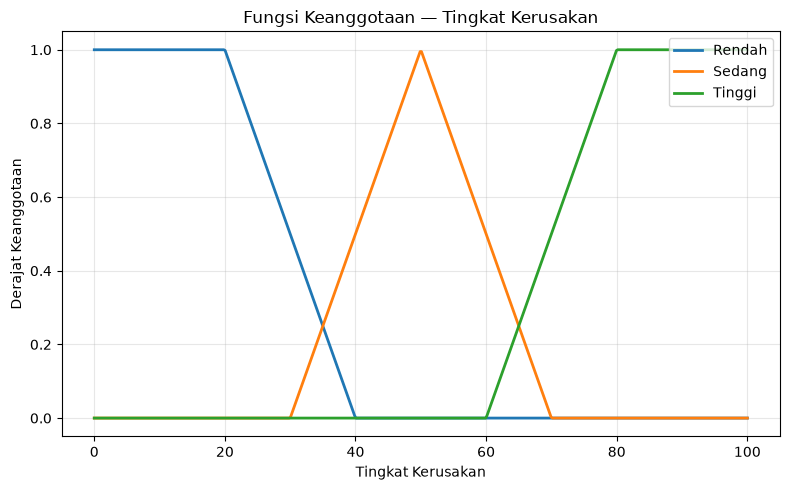

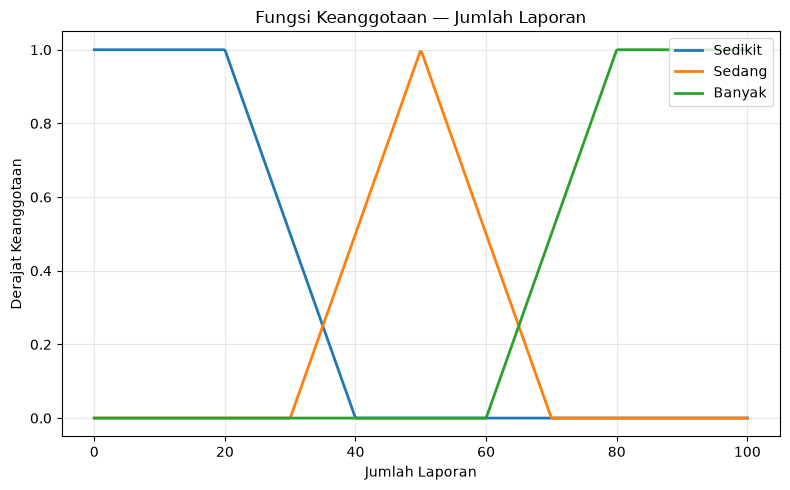

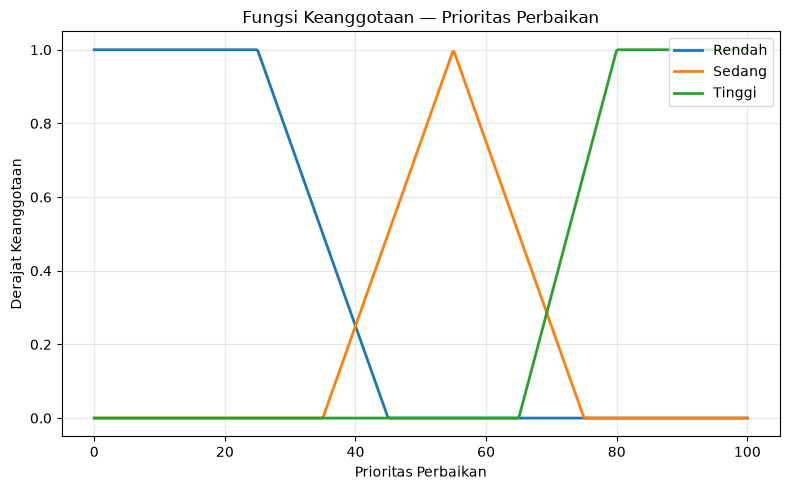

In [1]:
import numpy as np
import matplotlib.pyplot as plt

# ==================================================
# FUNGSI KEANGGOTAAN SEGITIGA
# ==================================================
def triangular(x, a, b, c):
    if x <= a or x >= c:
        return 0.0
    if x == b:
        return 1.0
    if x < b:
        return (x - a) / (b - a)
    return (c - x) / (c - b)

# ==================================================
# FUNGSI KEANGGOTAAN TRAPESIUM
# ==================================================
def trapezoidal(x, a, b, c, d):
    if x < a or x > d:
        return 0.0
    if b <= x <= c:
        return 1.0
    if x < b:
        if a == b:
            return 1.0
        return (x - a) / (b - a)
    if c == d:
        return 1.0
    return (d - x) / (d - c)

# ==================================================
# MODEL VARIABEL FUZZY
# ==================================================
variabel_fuzzy = {
    "Tingkat Kerusakan": {
        "domain": (0, 100),
        "Rendah":   {"tipe": "trapesium", "parameter": (0, 0, 20, 40)},
        "Sedang":   {"tipe": "segitiga",  "parameter": (30, 50, 70)},
        "Tinggi":   {"tipe": "trapesium", "parameter": (60, 80, 100, 100)}
    },
    "Jumlah Laporan": {
        "domain": (0, 100),
        "Sedikit":  {"tipe": "trapesium", "parameter": (0, 0, 20, 40)},
        "Sedang":   {"tipe": "segitiga",  "parameter": (30, 50, 70)},
        "Banyak":   {"tipe": "trapesium", "parameter": (60, 80, 100, 100)}
    },
    "Prioritas Perbaikan": {
        "domain": (0, 100),
        "Rendah":   {"tipe": "trapesium", "parameter": (0, 0, 25, 45)},
        "Sedang":   {"tipe": "segitiga",  "parameter": (35, 55, 75)},
        "Tinggi":   {"tipe": "trapesium", "parameter": (65, 80, 100, 100)}
    }
}

# ==================================================
# HITUNG DERAJAT KEANGGOTAAN
# ==================================================
def hitung_keanggotaan(x, tipe, parameter):
    if tipe == "segitiga":
        return triangular(x, *parameter)
    elif tipe == "trapesium":
        return trapezoidal(x, *parameter)

# ==================================================
# FUNGSI FUZZIFIKASI
# ==================================================
def fuzzifikasi(input_dict):
    hasil = {}
    nk = input_dict["kerusakan"]
    hasil["Tingkat Kerusakan"] = {
        lbl: hitung_keanggotaan(nk, d["tipe"], d["parameter"])
        for lbl, d in variabel_fuzzy["Tingkat Kerusakan"].items() if lbl != "domain"
    }
    nl = input_dict["laporan"]
    hasil["Jumlah Laporan"] = {
        lbl: hitung_keanggotaan(nl, d["tipe"], d["parameter"])
        for lbl, d in variabel_fuzzy["Jumlah Laporan"].items() if lbl != "domain"
    }
    return hasil

# ==================================================
# FUNGSI VISUALISASI
# ==================================================
def plot_variabel(nama_variabel, nama_file):
    data = variabel_fuzzy[nama_variabel]
    x = np.linspace(*data["domain"], 500)
    plt.figure(figsize=(8, 5))
    for lbl, d in data.items():
        if lbl == "domain":
            continue
        y = [hitung_keanggotaan(xi, d["tipe"], d["parameter"]) for xi in x]
        plt.plot(x, y, label=lbl, linewidth=2)
    plt.title(f"Fungsi Keanggotaan — {nama_variabel}", fontsize=12)
    plt.xlabel(nama_variabel, fontsize=10)
    plt.ylabel("Derajat Keanggotaan", fontsize=10)
    plt.ylim(-0.05, 1.05)
    plt.grid(True, alpha=0.3)
    plt.legend(loc="upper right")
    plt.tight_layout()
    plt.savefig(nama_file, dpi=300)
    plt.show()

# ==================================================
# DATA UJI
# ==================================================
data_uji = [
    {"kasus": "Ekstrem Bawah",        "kerusakan": 0,  "laporan": 0},
    {"kasus": "Kondisi Tengah",       "kerusakan": 50, "laporan": 50},
    {"kasus": "Batas Transisi Bawah", "kerusakan": 40, "laporan": 40},
    {"kasus": "Batas Transisi Atas",    "kerusakan": 60, "laporan": 60},
    {"kasus": "Ekstrem Atas",         "kerusakan": 100,"laporan": 100}
]

# ==================================================
# TAMPILKAN HASIL
# ==================================================
for d in data_uji:
    h = fuzzifikasi({"kerusakan": d["kerusakan"], "laporan": d["laporan"]})
    print(f"\n{'='*40}")
    print(f"Kasus: {d['kasus']}")
    print(f"Tingkat Kerusakan: {d['kerusakan']}%")
    print(f"Jumlah Laporan: {d['laporan']}")
    print(f"  Kerusakan → {h['Tingkat Kerusakan']}")
    print(f"  Laporan   → {h['Jumlah Laporan']}")

# ==================================================
# SIMPAN GRAFIK
# ==================================================
plot_variabel("Tingkat Kerusakan",   "grafik_tingkat_kerusakan.png")
plot_variabel("Jumlah Laporan",      "grafik_jumlah_laporan.png")
plot_variabel("Prioritas Perbaikan", "grafik_prioritas_perbaikan.png")
